In [14]:
# ==========================================
# SETUP & DATA LOADING
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a professional visual theme for the presentation
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the final dataset engineered by Member 1
df = pd.read_csv('swiggy_data_final.csv')
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# Extract useful time features for plotting
df['Month'] = df['Timestamp'].dt.month
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.day_name()

print("Data loaded successfully. Ready for EDA!")

Data loaded successfully. Ready for EDA!


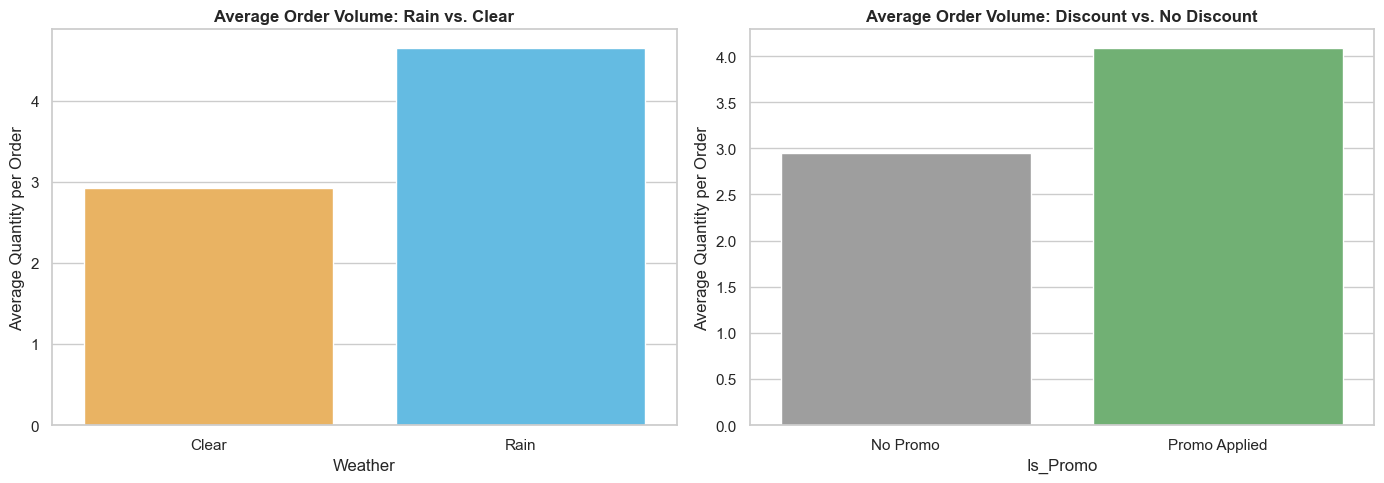

In [17]:
# ==========================================
# THE IMPACT OF WEATHER & PROMOTIONS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Weather Impact
# FIX: Added hue='Weather' and legend=False to satisfy modern seaborn requirements
sns.barplot(data=df, x='Weather', y='Quantity', hue='Weather', errorbar=None, 
            palette=['#FFB74D', '#4FC3F7'], legend=False, ax=axes[0])
axes[0].set_title('Average Order Volume: Rain vs. Clear', fontweight='bold')
axes[0].set_ylabel('Average Quantity per Order')

# Plot 2: Promo Impact
# FIX: Added hue='Is_Promo' and legend=False
sns.barplot(data=df, x='Is_Promo', y='Quantity', hue='Is_Promo', errorbar=None, 
            palette=['#9E9E9E', '#66BB6A'], legend=False, ax=axes[1])
axes[1].set_title('Average Order Volume: Discount vs. No Discount', fontweight='bold')
axes[1].set_ylabel('Average Quantity per Order')

# FIX: Explicitly set the tick locations before applying the text labels
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No Promo', 'Promo Applied'])

plt.tight_layout()
plt.show()

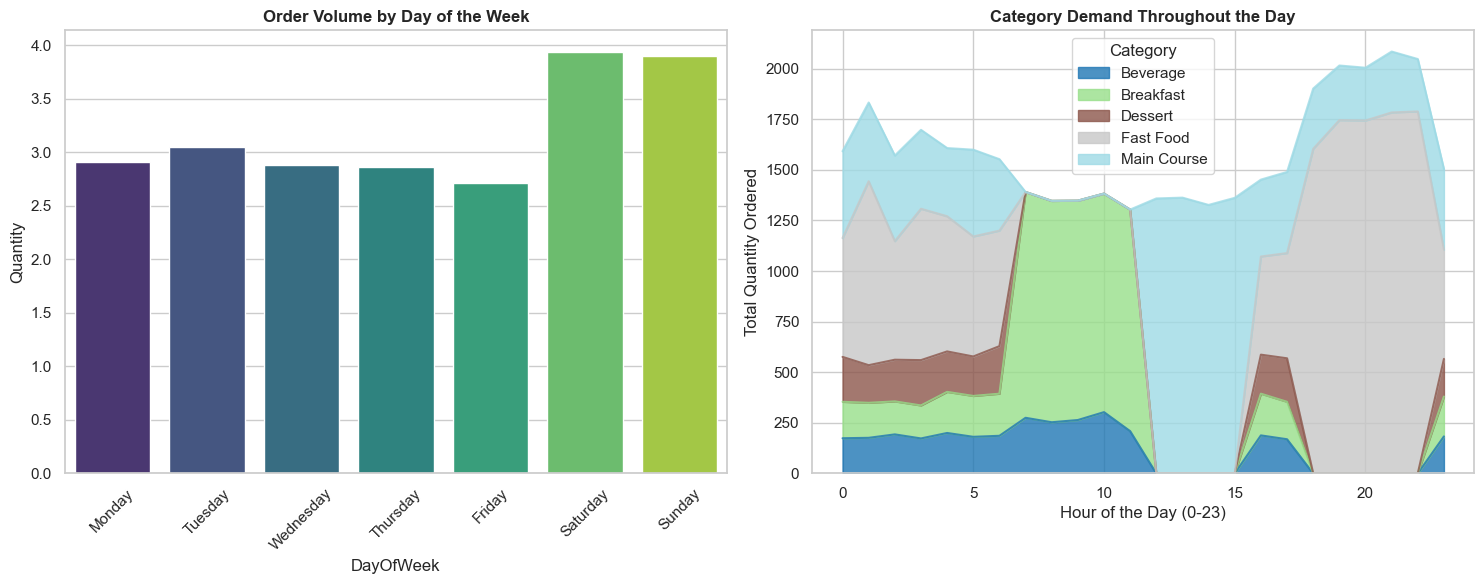

In [18]:
# ==========================================
# DAY OF WEEK AND HOURLY TRENDS
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Weekend vs Weekday
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

# FIX: Added hue='DayOfWeek' and legend=False
sns.barplot(data=df, x='DayOfWeek', y='Quantity', hue='DayOfWeek', order=day_order, 
            errorbar=None, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title('Order Volume by Day of the Week', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Hourly Category Preferences
hourly_cat = df.groupby(['Hour', 'Category'])['Quantity'].sum().unstack()
hourly_cat.plot(kind='area', stacked=True, colormap='tab20', ax=axes[1], alpha=0.8)
axes[1].set_title('Category Demand Throughout the Day', fontweight='bold')
axes[1].set_xlabel('Hour of the Day (0-23)')
axes[1].set_ylabel('Total Quantity Ordered')

plt.tight_layout()
plt.show()

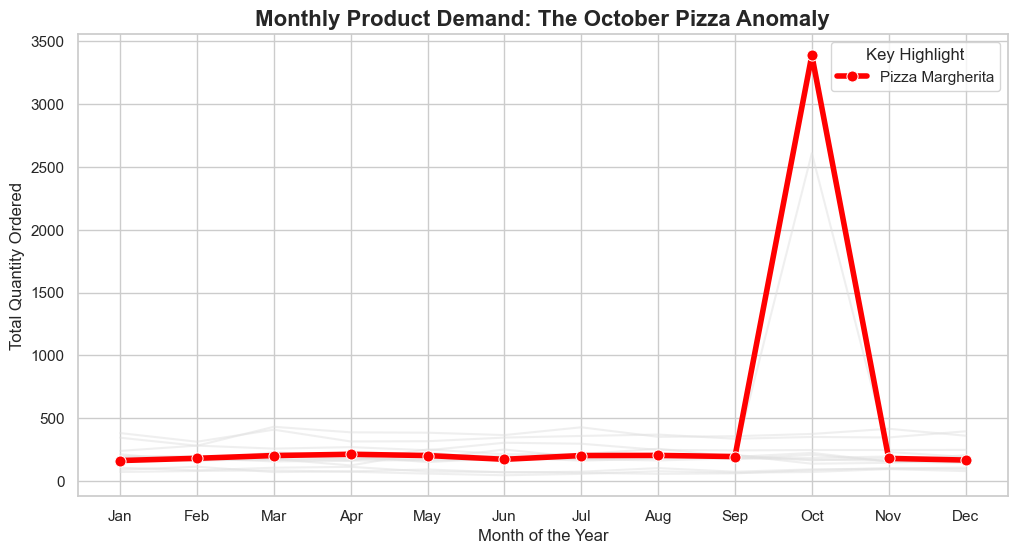

In [19]:
# ==========================================
# DISCOVERING THE OCTOBER SPIKE
# ==========================================
# Group data by Month and Product
monthly_trends = df.groupby(['Month', 'Product_Name'])['Quantity'].sum().reset_index()

plt.figure(figsize=(12, 6))

# Plot all products as light grey lines in the background
sns.lineplot(data=monthly_trends, x='Month', y='Quantity', hue='Product_Name', 
             palette=['#E0E0E0']*len(monthly_trends['Product_Name'].unique()), 
             legend=False, alpha=0.5, linewidth=1.5)

# Highlight Pizza Margherita specifically to show the spike
pizza_data = monthly_trends[monthly_trends['Product_Name'] == 'Pizza Margherita']
sns.lineplot(data=pizza_data, x='Month', y='Quantity', color='red', 
             linewidth=4, marker='o', markersize=8, label='Pizza Margherita')

plt.title('Monthly Product Demand: The October Pizza Anomaly', fontsize=16, fontweight='bold')
plt.xlabel('Month of the Year')
plt.ylabel('Total Quantity Ordered')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(title='Key Highlight')
plt.show()